# 03 Raw Regime-Conditional Correlations

This notebook rebuilds the raw correlation analysis from the project database. It starts from daily ETF log returns that have already been labeled with the monthly Markov stress regime, computes Pearson correlation matrices separately for calm and stress days, stores the canonical outputs in DuckDB, and produces the tables and figures used for interpretation.

The upstream dependency is `etf_returns_monthly_markov_labeled`, which is created by `scripts/06_assign_monthly_markov_regimes_to_daily_returns.py`. If that table is missing, run the upstream scripts listed below before executing this notebook.

## 1. Setup

The setup uses the repository-anchored `settings` paths, so the notebook works whether it is
launched from the project root or from `notebooks/` and always reads the local project
database. All figures (PNG) and tables (CSV) are written to `outputs/03_correlation_raw/`,
from where the report picks them up.

In [1]:
# =====================================================================
# Notebook 03 -- Raw Regime-Conditional Correlations: setup
#
# Reads daily ETF log returns labeled with the monthly Markov stress regime,
# computes calm/stress Pearson correlation matrices per universe, persists the
# canonical tables to DuckDB, and writes every report figure (PNG) and table
# (CSV) to outputs/03_correlation_raw/ so the correlation section is reproducible.
# =====================================================================
from __future__ import annotations

from pathlib import Path
import subprocess
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Bootstrap src/ from the notebook (or project-root) location, then use the
# repository-anchored settings paths so outputs are independent of the cwd.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import settings
from analysis.regime_correlations import (
    CORRELATION_METHOD,
    build_universe_correlation_outputs,
    common_complete_case_dates,
    correlation_matrices,
    pair_ranking_from_pairs,
    prepare_labeled_returns,
    select_return_columns,
    write_correlation_outputs,
)
from features.regime_assignment import ETF_TABLE

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

DB_PATH = settings.DB_PATH
SCHEMA_DIR = settings.PROJECT_ROOT / "sql" / "schema"
OUTPUT_DIR = settings.PROJECT_ROOT / "outputs" / "03_correlation_raw"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Database: {DB_PATH}")
print(f"Outputs : {OUTPUT_DIR}")

Database: C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\data\lsr.duckdb
Outputs : C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\outputs\03_correlation_raw


## 2. Reproducibility Switches

By default the notebook does not re-download market prices or rebuild the Markov regime model. Set `RUN_UPSTREAM_PIPELINE = True` only when you want to rebuild all prerequisites from scratch. That step can take time and may require internet access for Yahoo Finance data.

The correlation tables are rebuilt by default because they are the direct outputs of this notebook.

In [2]:
RUN_UPSTREAM_PIPELINE = False
REBUILD_CORRELATION_TABLES = False
WRITE_TO_DATABASE = False

UPSTREAM_SCRIPTS = [
    "01_init_database.py",
    "02_fetch_market_prices.py",
    "04_build_regime_labels.py",
    "05_00_build_markov_switching_monthly.py",
    "06_assign_monthly_markov_regimes_to_daily_returns.py",
]

if RUN_UPSTREAM_PIPELINE:
    for script_name in UPSTREAM_SCRIPTS:
        script_path = PROJECT_ROOT / "scripts" / script_name
        print(f"Running {script_path.relative_to(PROJECT_ROOT)}")
        subprocess.run([sys.executable, str(script_path)], cwd=PROJECT_ROOT, check=True)
else:
    print("Skipping upstream rebuild. Using the existing DuckDB tables.")

Skipping upstream rebuild. Using the existing DuckDB tables.


## 3. Database Checks

The raw correlation step needs the labeled daily ETF return table. The cell below fails early with a clear message if the table is not available.

In [3]:
settings.require_data_dir()
if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found: {DB_PATH}. Run scripts/01_init_database.py and the upstream pipeline first."
    )

con = duckdb.connect(str(DB_PATH))
available_tables = set(con.execute("SHOW TABLES").fetchdf()["name"])
print(f"Database: {DB_PATH}")
print(f"Available tables: {len(available_tables)}")

if ETF_TABLE not in available_tables:
    raise RuntimeError(
        f"Missing required table: {ETF_TABLE}. Run scripts/06_assign_monthly_markov_regimes_to_daily_returns.py first."
    )

sorted(table for table in available_tables if "correlation" in table or "markov" in table or "return" in table)

Database: C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\data\lsr.duckdb
Available tables: 19


['correlation_pairs',
 'correlation_summary',
 'etf_returns_monthly_markov_labeled',
 'markov_model_summary',
 'markov_monthly_comparison',
 'markov_regime_monthly',
 'markov_regime_weekly',
 'markov_weekly_comparison',
 'markov_weekly_model_summary',
 'markov_weekly_vs_monthly_comparison']

## 4. Load Labeled Returns

The analysis uses complete-case daily log returns and the monthly Markov stress label `ms_stress`. Calm days are encoded as `0`; stress days are encoded as `1`.

In [4]:
raw_labeled = con.execute(f"SELECT * FROM {ETF_TABLE} ORDER BY date").fetchdf()
raw_labeled["date"] = pd.to_datetime(raw_labeled["date"])

all_return_columns = select_return_columns(raw_labeled)
print(f"Raw rows: {len(raw_labeled):,}")
print(f"Available return columns: {len(all_return_columns)}")
print(all_return_columns)

raw_labeled.head()

Raw rows: 6,518
Available return columns: 14
['AGG', 'DBC', 'EEM', 'EFA', 'EWG', 'EWJ', 'EWU', 'GLD', 'HYG', 'SHY', 'SPY', 'TLT', 'USO', 'VNQ']


,date,AGG,DBC,EEM,EFA,EWG,EWJ,EWU,GLD,HYG,SHY,SPY,TLT,USO,VNQ,ms_stress,ms_prob_stress,created_at
0,2000-02-01,NaN,NaN,NaN,NaN,0.012331,0.000000,0.000000,NaN,NaN,NaN,0.009804,NaN,NaN,NaN,1,0.922222,2026-07-04 17:20:09.698102
1,2000-02-02,NaN,NaN,NaN,NaN,0.031365,0.008098,0.006390,NaN,NaN,NaN,0.000886,NaN,NaN,NaN,1,0.922222,2026-07-04 17:20:09.698102
2,2000-02-03,NaN,NaN,NaN,NaN,0.041867,0.016000,-0.003190,NaN,NaN,NaN,0.014953,NaN,NaN,NaN,1,0.922222,2026-07-04 17:20:09.698102
3,2000-02-04,NaN,NaN,NaN,NaN,0.009071,0.015748,-0.032471,NaN,NaN,NaN,-0.004156,NaN,NaN,NaN,1,0.922222,2026-07-04 17:20:09.698102
4,2000-02-07,NaN,NaN,NaN,NaN,-0.025144,-0.015748,-0.009950,NaN,NaN,NaN,-0.001534,NaN,NaN,NaN,1,0.922222,2026-07-04 17:20:09.698102


In [5]:
regime_sample = (
    raw_labeled.dropna(subset=["ms_stress"])
    .assign(ms_stress=lambda df: df["ms_stress"].astype(int))
    .groupby("ms_stress")
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        rows=("date", "count"),
        avg_prob_stress=("ms_prob_stress", "mean"),
    )
    .rename(index={0: "calm", 1: "stress"})
)
regime_sample

,first_date,last_date,rows,avg_prob_stress
ms_stress,,,,
calm,2003-05-01,2025-12-30,3436,0.128955
stress,2000-02-01,2025-03-31,3082,0.898092


## 5. Define Correlation Universes

The notebook computes three views:

- `panel_a_cross_asset`: the cross-asset panel from `settings.PANEL_A`.
- `panel_b_international_equity`: the international equity panel from `settings.PANEL_B`.
- `etf_assets`: the full available ETF universe, matching the canonical pipeline table name.

Only tickers present in the labeled return table are used, which keeps the notebook robust if the configured universe changes before the database is rebuilt.

In [6]:
def available_configured_tickers(tickers: list[str], available_columns: list[str]) -> list[str]:
    return [ticker for ticker in tickers if ticker in available_columns]

universe_columns = {
    "panel_a_cross_asset": available_configured_tickers(settings.PANEL_A, all_return_columns),
    "panel_b_international_equity": available_configured_tickers(settings.PANEL_B, all_return_columns),
    "etf_assets": all_return_columns,
}

universe_columns = {
    name: columns for name, columns in universe_columns.items() if len(columns) >= 2
}

universe_overview = pd.DataFrame(
    [
        {"universe": name, "n_assets": len(columns), "assets": ", ".join(columns)}
        for name, columns in universe_columns.items()
    ]
)
universe_overview

,universe,n_assets,assets
0,panel_a_cross_asset,9,"SPY, SHY, TLT, AGG, HYG, GLD, DBC, USO, VNQ"
1,panel_b_international_equity,6,"SPY, EFA, EEM, EWG, EWU, EWJ"
2,etf_assets,14,"AGG, DBC, EEM, EFA, EWG, EWJ, EWU, GLD, HYG, S..."


## 6. Compute Raw Correlations

For each universe, the notebook computes:

- a calm correlation matrix;
- a stress correlation matrix;
- a stress-minus-calm difference matrix;
- one summary row with average, median, percentile, minimum, and maximum pairwise correlations;
- a long pair table with one row per asset pair and regime.

In [7]:
# Portfolio-level aggregates are computed on the common balanced window (the dates
# where all combined-universe assets are observed), so every panel shares the same
# trading days and calm/stress mix. Panel A and the combined universe already sit on
# this window; only Panel B (no HYG, no commodities) is shortened. This keeps the
# correlation aggregates consistent with the PCA concentration measures.
common_dates = common_complete_case_dates(raw_labeled, all_return_columns)
print(
    f"common window: {common_dates.min().date()} -> {common_dates.max().date()} "
    f"({len(common_dates):,} trading days)"
)

universe_data: dict[str, pd.DataFrame] = {}
matrices_by_universe: dict[str, dict[str, pd.DataFrame]] = {}
summary_frames: list[pd.DataFrame] = []
pair_frames: list[pd.DataFrame] = []

for universe, columns in universe_columns.items():
    data = prepare_labeled_returns(raw_labeled, columns, restrict_dates=common_dates)
    matrices = correlation_matrices(data, columns)
    summary, pairs = build_universe_correlation_outputs(data, columns, universe)

    universe_data[universe] = data
    matrices_by_universe[universe] = matrices
    summary_frames.append(summary)
    pair_frames.append(pairs)

summary = pd.concat(summary_frames, ignore_index=True)
pairs = pd.concat(pair_frames, ignore_index=True)

common window: 2007-04-12 -> 2025-12-30 (4,711 trading days)


In [8]:
summary_display = summary.copy()
metric_columns = [column for column in summary_display.columns if column.endswith(("calm", "stress", "diff"))]
summary_display[metric_columns] = summary_display[metric_columns].round(4)
summary_display.sort_values("universe")

,universe,method,n_assets,n_pairs,n_calm_days,n_stress_days,avg_corr_calm,avg_corr_stress,avg_corr_diff,median_corr_calm,median_corr_stress,median_corr_diff,p10_corr_calm,p10_corr_stress,p10_corr_diff,p90_corr_calm,p90_corr_stress,p90_corr_diff,min_corr_calm,min_corr_stress,max_corr_calm,max_corr_stress
2,etf_assets,pearson,14,91,2443,2268,0.2818,0.3108,0.0291,0.2403,0.3425,0.0499,-0.1316,-0.2518,-0.1503,0.7312,0.8542,0.1949,-0.2208,-0.3581,0.9119,0.9494
0,panel_a_cross_asset,pearson,9,36,2443,2268,0.1949,0.1703,-0.0246,0.1612,0.1700,-0.0243,-0.1519,-0.2552,-0.2220,0.6252,0.6051,0.1730,-0.2208,-0.3581,0.8770,0.8413
1,panel_b_international_equity,pearson,6,15,2443,2268,0.7411,0.8655,0.1245,0.7303,0.8583,0.1247,0.6080,0.8004,0.0579,0.8695,0.9327,0.1906,0.5958,0.7973,0.9119,0.9494


## 7. Persist Canonical Outputs

This cell rebuilds the two canonical raw-correlation tables:

- `correlation_summary`
- `correlation_pairs`

Set `WRITE_TO_DATABASE = False` above if you only want in-memory notebook results.

In [9]:
if WRITE_TO_DATABASE:
    if REBUILD_CORRELATION_TABLES:
        for schema_file in ["07_correlation_summary.sql", "07_correlation_pairs.sql"]:
            schema_sql = (SCHEMA_DIR / schema_file).read_text(encoding="utf-8")
            con.execute(schema_sql)

    con.register("summary", summary)
    con.register("pairs", pairs)
    write_correlation_outputs(con, summary, pairs)
    con.commit()

    persisted_counts = {
        table: con.execute(f"SELECT COUNT(*) AS n FROM {table}").fetchone()[0]
        for table in ["correlation_summary", "correlation_pairs"]
    }
    print(persisted_counts)
else:
    print("Database write skipped.")

Database write skipped.


## 8. Correlation Matrices

The heatmaps show how the dependence structure changes between calm and stress states. The difference matrix is stress minus calm, so positive values indicate stronger comovement during stress.

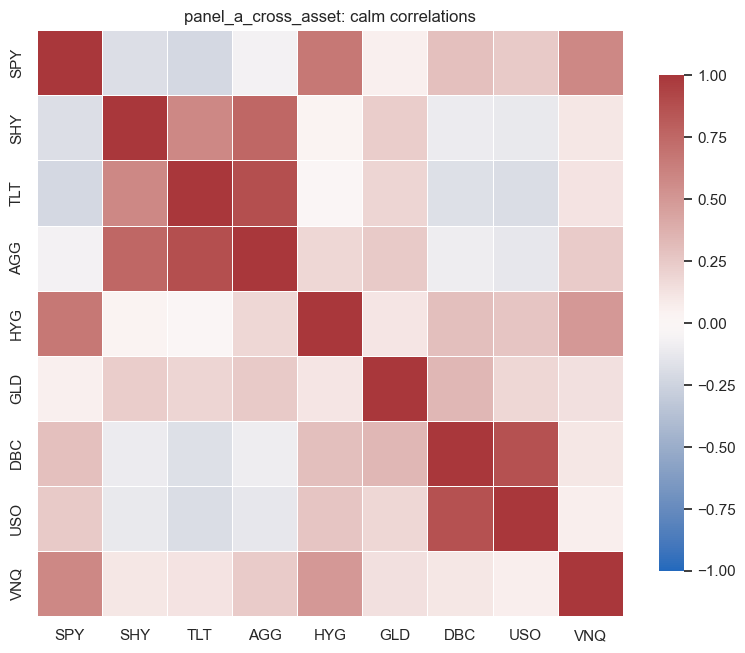

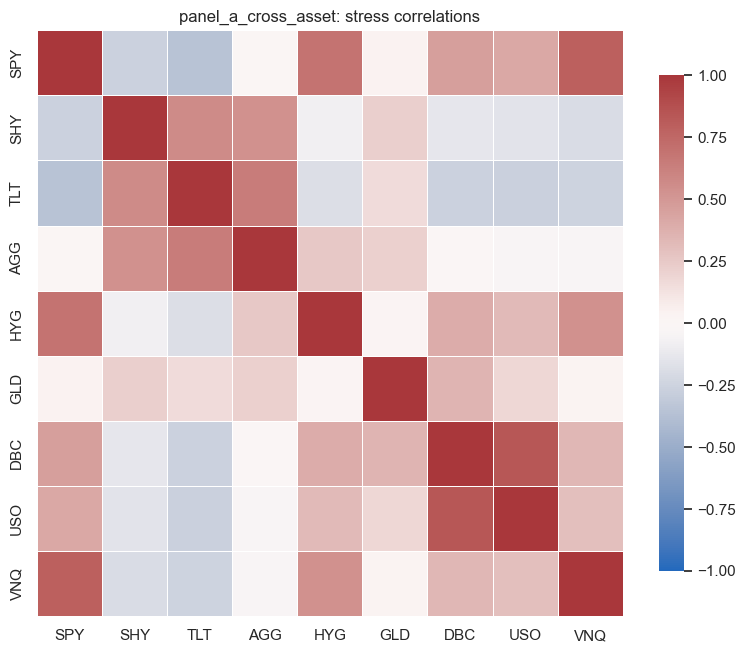

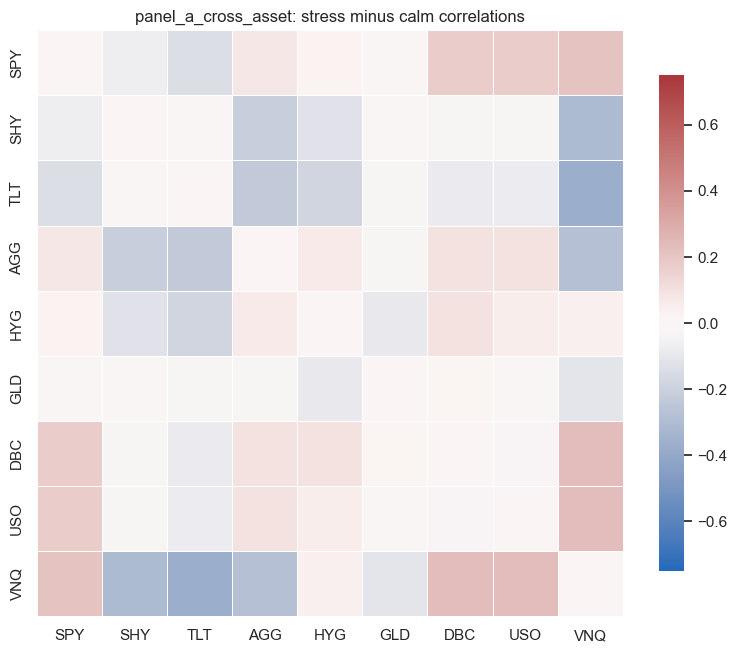

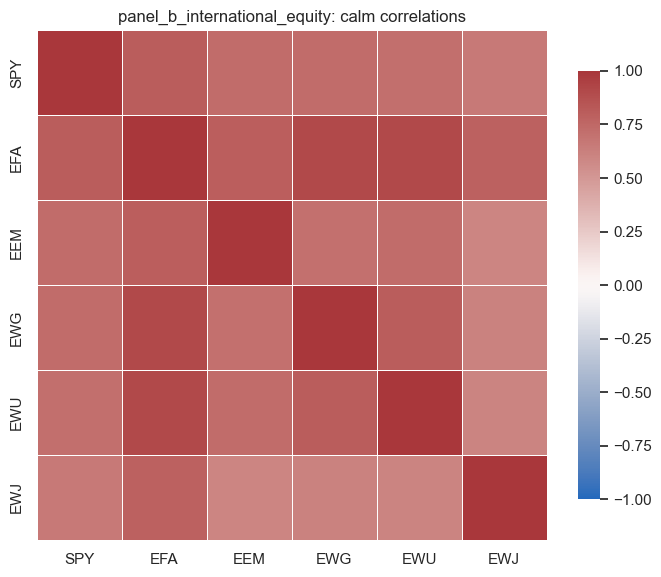

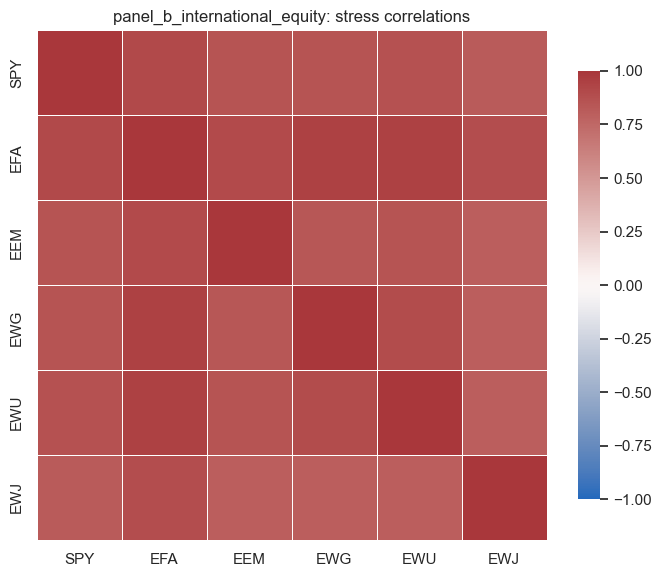

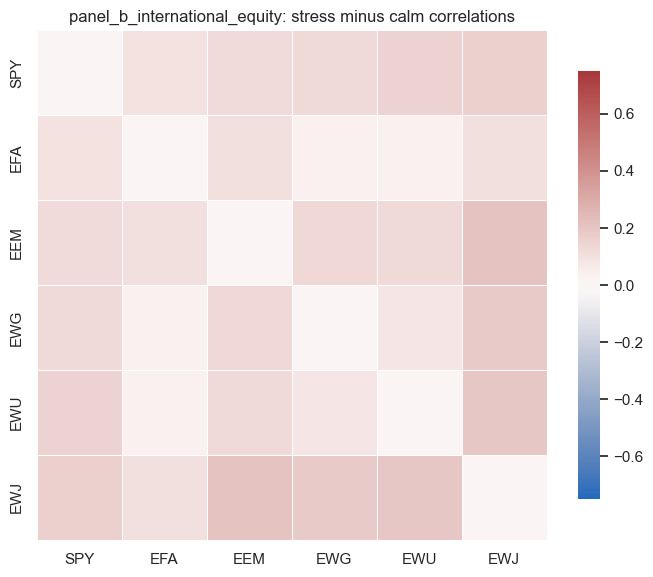

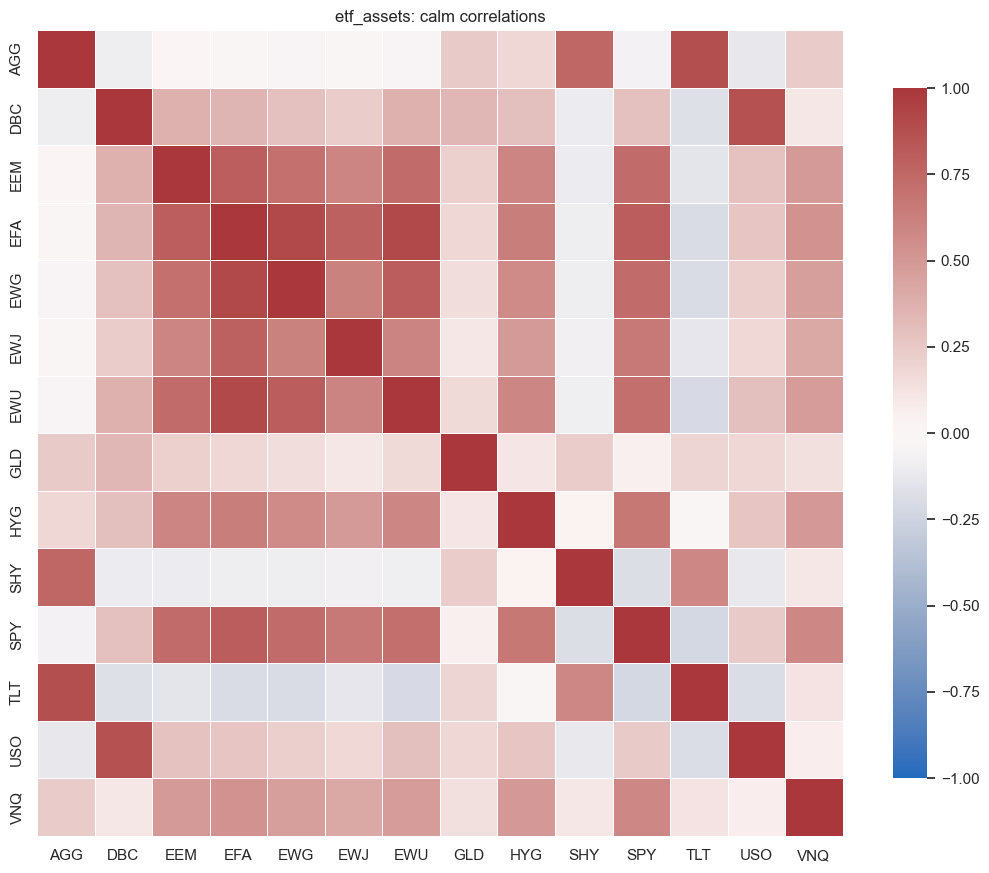

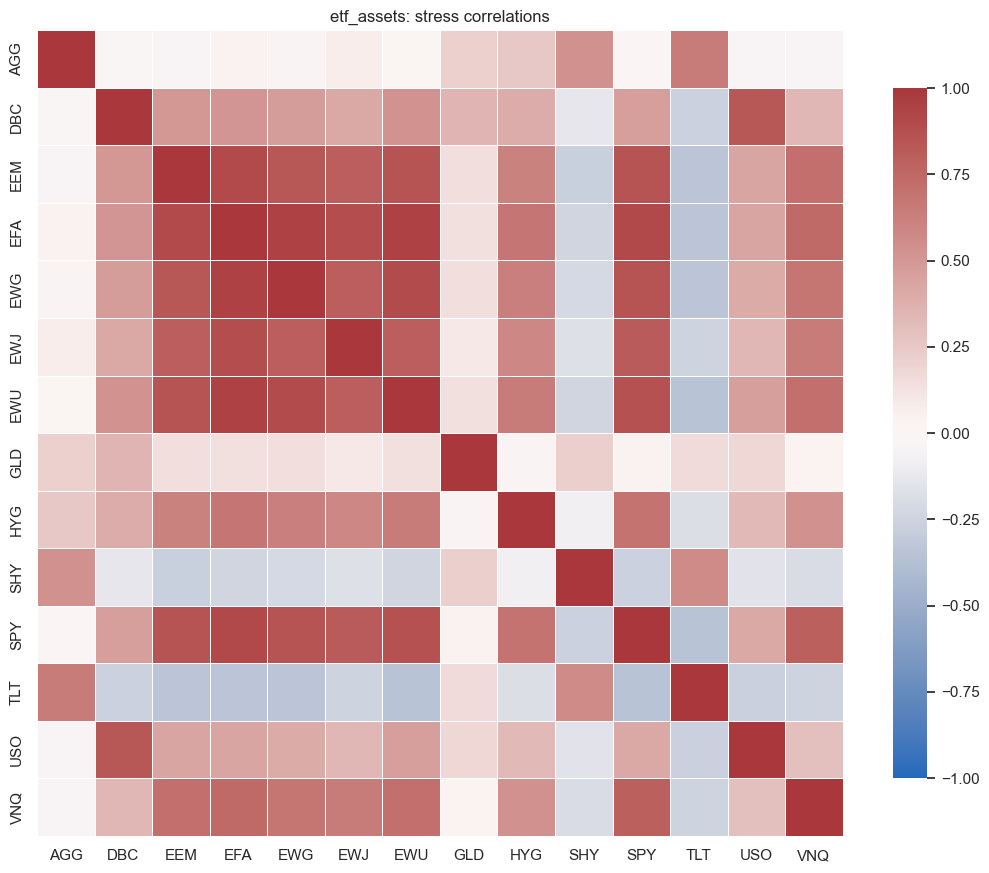

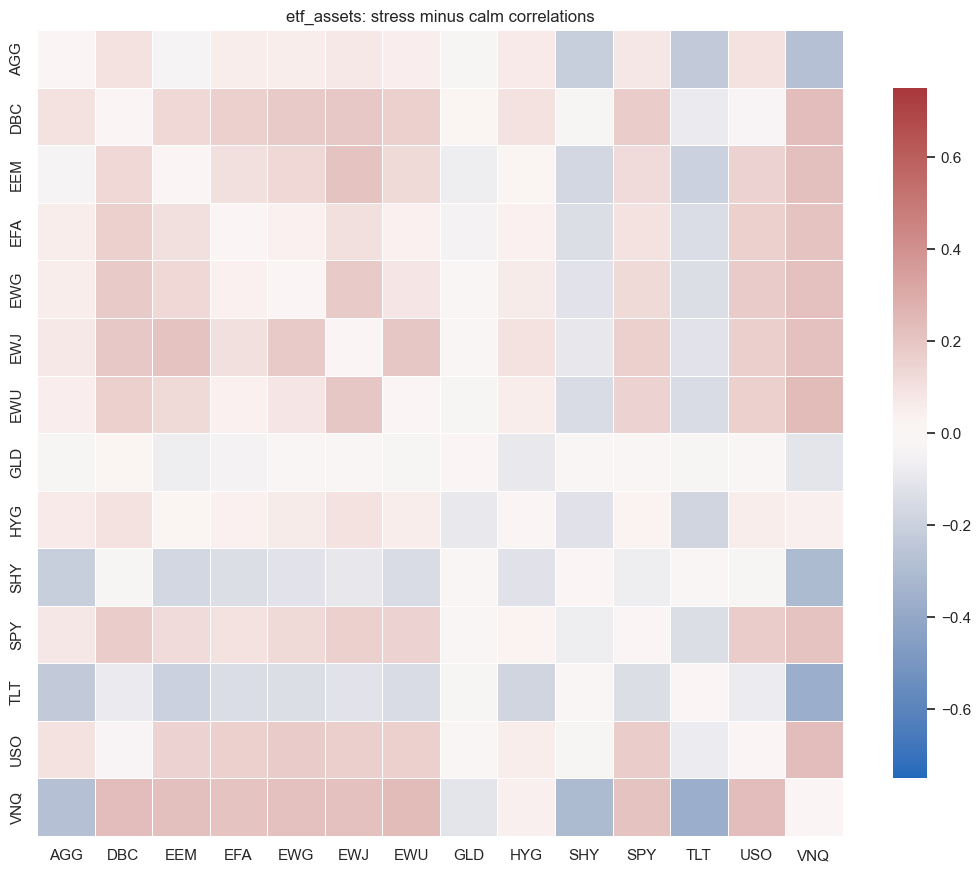

In [10]:
def plot_correlation_heatmap(
    matrix: pd.DataFrame,
    title: str,
    path: Path,
    *,
    vmin: float,
    vmax: float,
    center: float,
    cmap: str,
) -> None:
    size = max(7, 0.55 * len(matrix.columns) + 3)
    fig, ax = plt.subplots(figsize=(size, size * 0.85))
    sns.heatmap(
        matrix,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        center=center,
        cmap=cmap,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()

for universe, matrices in matrices_by_universe.items():
    for regime, matrix in matrices.items():
        is_difference = regime == "stress_minus_calm"
        plot_correlation_heatmap(
            matrix,
            title=f"{universe}: {regime.replace('_', ' ')} correlations",
            path=OUTPUT_DIR / f"{universe}_{regime}_heatmap.png",
            vmin=-1 if not is_difference else -0.75,
            vmax=1 if not is_difference else 0.75,
            center=0,
            cmap="vlag",
        )

## 9. Pair-Level Ranking

The ranking highlights which asset pairs experience the largest correlation increases or decreases in stress. This is the most direct raw evidence for correlation breakdown or resilience.

In [11]:
rankings = {
    universe: pair_ranking_from_pairs(pairs, universe)
    for universe in universe_columns
}

for universe, ranking in rankings.items():
    display_columns = ["asset_i", "asset_j", "corr_calm", "corr_stress", "delta_corr", "interpretation"]
    display_df = ranking[display_columns].copy()
    display_df[["corr_calm", "corr_stress", "delta_corr"]] = display_df[
        ["corr_calm", "corr_stress", "delta_corr"]
    ].round(4)
    print(f"\nTop correlation increases: {universe}")
    display(display_df.head(10))


Top correlation increases: panel_a_cross_asset


,asset_i,asset_j,corr_calm,corr_stress,delta_corr,interpretation
0,DBC,VNQ,0.1081,0.3408,0.2327,Moderate breakdown
1,USO,VNQ,0.0671,0.2984,0.2313,Moderate breakdown
2,SPY,VNQ,0.5850,0.7948,0.2098,Moderate breakdown
3,SPY,DBC,0.2939,0.4679,0.1740,Moderate breakdown
4,SPY,USO,0.2467,0.4187,0.1720,Moderate breakdown
5,AGG,DBC,-0.1001,-0.0015,0.0986,Small increase
6,AGG,USO,-0.1316,-0.0333,0.0983,Small increase
7,HYG,DBC,0.2972,0.3936,0.0964,Small increase
8,SPY,AGG,-0.0694,0.0081,0.0776,Small increase
9,AGG,HYG,0.1850,0.2507,0.0657,Small increase



Top correlation increases: panel_b_international_equity


,asset_i,asset_j,corr_calm,corr_stress,delta_corr,interpretation
0,EEM,EWJ,0.5958,0.8016,0.2058,Moderate breakdown
1,EWU,EWJ,0.6046,0.7995,0.1949,Moderate breakdown
2,EWG,EWJ,0.6131,0.7973,0.1842,Moderate breakdown
3,SPY,EWJ,0.6566,0.8164,0.1598,Moderate breakdown
4,SPY,EWU,0.7176,0.8675,0.1499,Moderate breakdown
5,EEM,EWG,0.7105,0.8410,0.1306,Moderate breakdown
6,EEM,EWU,0.7300,0.8583,0.1283,Moderate breakdown
7,SPY,EWG,0.7303,0.8550,0.1247,Moderate breakdown
8,SPY,EEM,0.7312,0.8542,0.1230,Moderate breakdown
9,EFA,EWJ,0.7854,0.8892,0.1038,Moderate breakdown



Top correlation increases: etf_assets


,asset_i,asset_j,corr_calm,corr_stress,delta_corr,interpretation
0,EWU,VNQ,0.4791,0.7136,0.2345,Moderate breakdown
1,DBC,VNQ,0.1081,0.3408,0.2327,Moderate breakdown
2,USO,VNQ,0.0671,0.2984,0.2313,Moderate breakdown
3,EEM,VNQ,0.4870,0.7150,0.2280,Moderate breakdown
4,EWG,VNQ,0.4636,0.6857,0.2220,Moderate breakdown
5,EWJ,VNQ,0.4204,0.6417,0.2213,Moderate breakdown
6,EFA,VNQ,0.5265,0.7365,0.2101,Moderate breakdown
7,SPY,VNQ,0.5850,0.7948,0.2098,Moderate breakdown
8,EEM,EWJ,0.5958,0.8016,0.2058,Moderate breakdown
9,EWJ,EWU,0.6046,0.7995,0.1949,Moderate breakdown


In [12]:
for universe, ranking in rankings.items():
    display_columns = ["asset_i", "asset_j", "corr_calm", "corr_stress", "delta_corr", "interpretation"]
    display_df = ranking.sort_values("delta_corr", ascending=True)[display_columns].copy()
    display_df[["corr_calm", "corr_stress", "delta_corr"]] = display_df[
        ["corr_calm", "corr_stress", "delta_corr"]
    ].round(4)
    print(f"\nTop correlation decreases: {universe}")
    display(display_df.head(10))


Top correlation decreases: panel_a_cross_asset


,asset_i,asset_j,corr_calm,corr_stress,delta_corr,interpretation
35,TLT,VNQ,0.1226,-0.2518,-0.3744,Correlation decreased
34,SHY,VNQ,0.1079,-0.1976,-0.3055,Correlation decreased
33,AGG,VNQ,0.2403,-0.0366,-0.2769,Correlation decreased
32,TLT,AGG,0.8770,0.6472,-0.2298,Correlation decreased
31,SHY,AGG,0.7522,0.5379,-0.2142,Correlation decreased
30,TLT,HYG,-0.0034,-0.1797,-0.1763,Correlation decreased
29,SPY,TLT,-0.2208,-0.3581,-0.1374,Correlation decreased
28,SHY,HYG,0.0358,-0.0846,-0.1204,Correlation decreased
27,GLD,VNQ,0.1398,0.0322,-0.1076,Correlation decreased
26,HYG,GLD,0.1142,0.0259,-0.0884,Correlation decreased



Top correlation decreases: panel_b_international_equity


,asset_i,asset_j,corr_calm,corr_stress,delta_corr,interpretation
14,EFA,EWG,0.9119,0.9494,0.0375,Small increase
13,EFA,EWU,0.9079,0.9484,0.0405,Small increase
12,EWG,EWU,0.8119,0.8958,0.0839,Small increase
11,SPY,EFA,0.8102,0.9090,0.0988,Small increase
10,EFA,EEM,0.7990,0.9004,0.1014,Moderate breakdown
9,EFA,EWJ,0.7854,0.8892,0.1038,Moderate breakdown
8,SPY,EEM,0.7312,0.8542,0.1230,Moderate breakdown
7,SPY,EWG,0.7303,0.8550,0.1247,Moderate breakdown
6,EEM,EWU,0.7300,0.8583,0.1283,Moderate breakdown
5,EEM,EWG,0.7105,0.8410,0.1306,Moderate breakdown



Top correlation decreases: etf_assets


,asset_i,asset_j,corr_calm,corr_stress,delta_corr,interpretation
90,TLT,VNQ,0.1226,-0.2518,-0.3744,Correlation decreased
89,SHY,VNQ,0.1079,-0.1976,-0.3055,Correlation decreased
88,AGG,VNQ,0.2403,-0.0366,-0.2769,Correlation decreased
87,AGG,TLT,0.8770,0.6472,-0.2298,Correlation decreased
86,AGG,SHY,0.7522,0.5379,-0.2142,Correlation decreased
85,EEM,TLT,-0.1419,-0.3411,-0.1991,Correlation decreased
84,HYG,TLT,-0.0034,-0.1797,-0.1763,Correlation decreased
83,EEM,SHY,-0.1046,-0.2770,-0.1724,Correlation decreased
82,EWU,SHY,-0.0897,-0.2404,-0.1507,Correlation decreased
81,EWU,TLT,-0.2055,-0.3558,-0.1503,Correlation decreased


## 10. Calm-vs-Stress Scatter

Pairs above the diagonal have higher correlations in stress than in calm. The farther a point is above the line, the larger the raw stress-period increase.

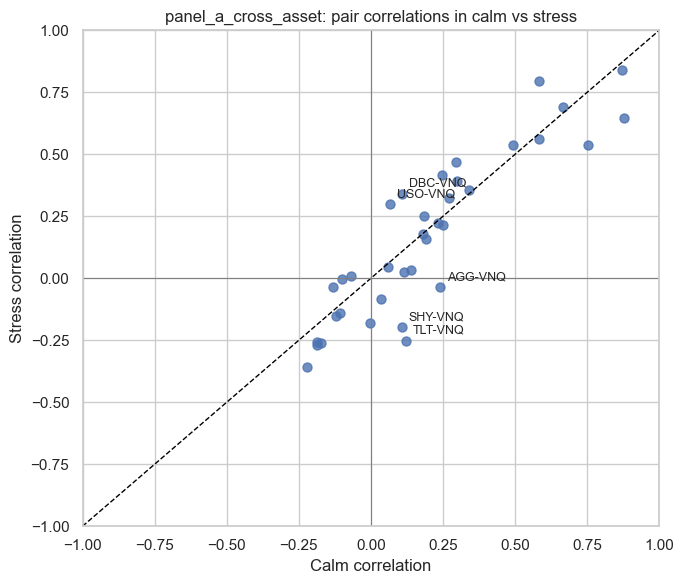

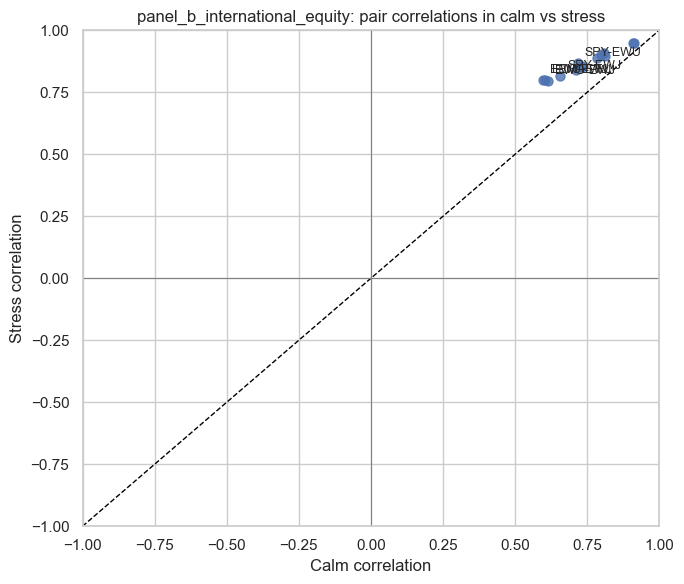

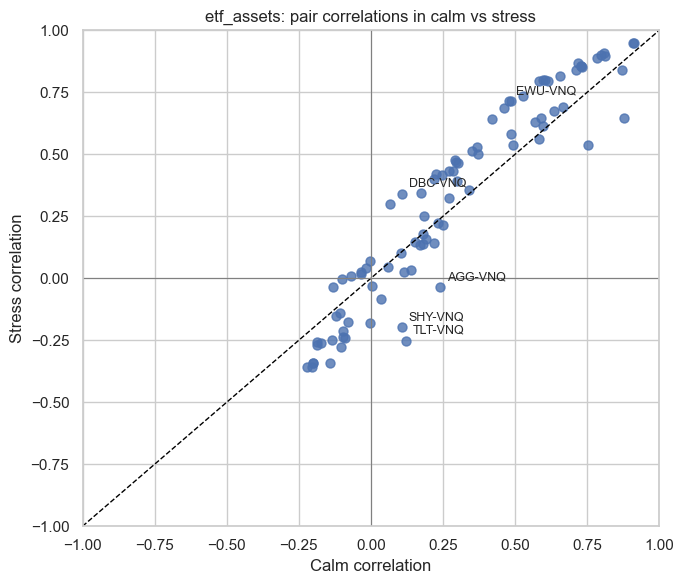

In [13]:
def plot_calm_stress_scatter(ranking: pd.DataFrame, universe: str) -> None:
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(ranking["corr_calm"], ranking["corr_stress"], s=42, alpha=0.8)
    ax.plot([-1, 1], [-1, 1], color="black", linewidth=1, linestyle="--")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Calm correlation")
    ax.set_ylabel("Stress correlation")
    ax.set_title(f"{universe}: pair correlations in calm vs stress")

    # Label the five pairs with the largest absolute change.
    top_labels = ranking.reindex(ranking["delta_corr"].abs().sort_values(ascending=False).head(5).index)
    for row in top_labels.itertuples(index=False):
        ax.annotate(
            f"{row.asset_i}-{row.asset_j}",
            (row.corr_calm, row.corr_stress),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{universe}_calm_vs_stress_scatter.png", dpi=180, bbox_inches="tight")
    plt.show()

for universe, ranking in rankings.items():
    plot_calm_stress_scatter(ranking, universe)

## 11. Distribution of Correlation Changes

This distribution summarizes whether stress mostly compresses assets into a more common factor structure or whether some pair relationships weaken.

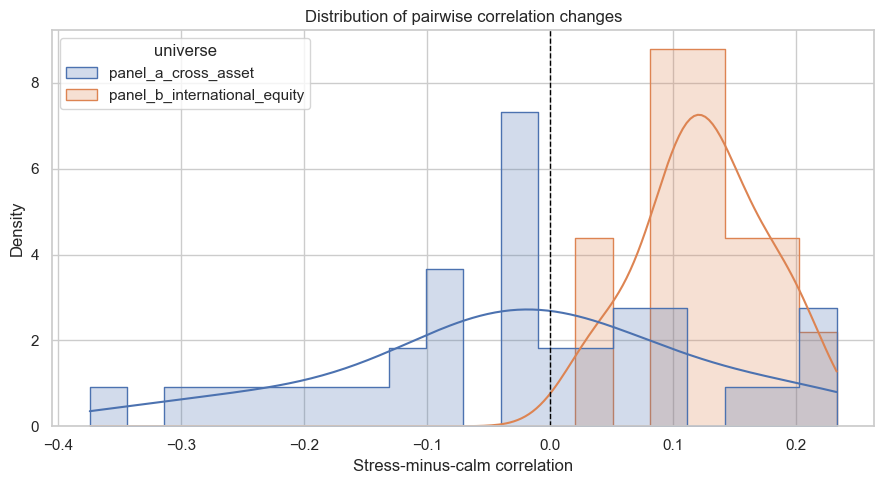

In [14]:
plot_rows = []
for universe, ranking in rankings.items():
    temp = ranking[["delta_corr"]].copy()
    temp["universe"] = universe
    plot_rows.append(temp)

delta_distribution = pd.concat(plot_rows, ignore_index=True)
delta_distribution_plot = delta_distribution[
    delta_distribution["universe"] != "etf_assets"
].copy()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=delta_distribution_plot,
    x="delta_corr",
    hue="universe",
    bins=20,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Stress-minus-calm correlation")
ax.set_ylabel("Density")
ax.set_title("Distribution of pairwise correlation changes")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "delta_corr_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## 12. Interpretation Table

The labels below are descriptive thresholds for the raw correlations only. They do not yet correct for stress-period volatility, which is handled separately in the Forbes-Rigobon adjusted correlation notebook/script.

In [15]:
interpretation_summary = []
for universe, ranking in rankings.items():
    counts = ranking["interpretation"].value_counts().rename_axis("interpretation").reset_index(name="n_pairs")
    counts["universe"] = universe
    counts["share"] = counts["n_pairs"] / counts["n_pairs"].sum()
    interpretation_summary.append(counts)

interpretation_summary = pd.concat(interpretation_summary, ignore_index=True)
interpretation_summary["share"] = interpretation_summary["share"].round(3)
interpretation_summary[["universe", "interpretation", "n_pairs", "share"]].sort_values(
    ["universe", "n_pairs"], ascending=[True, False]
)

,universe,interpretation,n_pairs,share
5,etf_assets,Correlation decreased,38,0.418
6,etf_assets,Moderate breakdown,31,0.341
7,etf_assets,Small increase,22,0.242
0,panel_a_cross_asset,Correlation decreased,22,0.611
1,panel_a_cross_asset,Small increase,9,0.250
2,panel_a_cross_asset,Moderate breakdown,5,0.139
3,panel_b_international_equity,Moderate breakdown,11,0.733
4,panel_b_international_equity,Small increase,4,0.267


## 13. Export Notebook Tables

The CSV files are lightweight reproducibility artifacts for reporting and appendix checks.

In [16]:
# Reproducible outputs: canonical tables and per-universe rankings (feed the report).
summary.to_csv(OUTPUT_DIR / "correlation_summary.csv", index=False)
pairs.to_csv(OUTPUT_DIR / "correlation_pairs.csv", index=False)
interpretation_summary.to_csv(OUTPUT_DIR / "correlation_interpretation_summary.csv", index=False)
for universe, ranking in rankings.items():
    ranking.to_csv(OUTPUT_DIR / f"{universe}_pair_ranking.csv", index=False)

written = [
    "correlation_summary.csv",
    "correlation_pairs.csv",
    "correlation_interpretation_summary.csv",
    *[f"{u}_pair_ranking.csv" for u in rankings],
    "delta_corr_distribution.png",
    *[f"{u}_stress_minus_calm_heatmap.png" for u in rankings],
    *[f"{u}_calm_vs_stress_scatter.png" for u in rankings],
]
print(f"Wrote reproducible outputs to {OUTPUT_DIR}:")
for name in written:
    status = "ok" if (OUTPUT_DIR / name).exists() else "MISSING"
    print(f"  [{status}] {name}")

Wrote reproducible outputs to C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\outputs\03_correlation_raw:
  [ok] correlation_summary.csv
  [ok] correlation_pairs.csv
  [ok] correlation_interpretation_summary.csv
  [ok] panel_a_cross_asset_pair_ranking.csv
  [ok] panel_b_international_equity_pair_ranking.csv
  [ok] etf_assets_pair_ranking.csv
  [ok] delta_corr_distribution.png
  [ok] panel_a_cross_asset_stress_minus_calm_heatmap.png
  [ok] panel_b_international_equity_stress_minus_calm_heatmap.png
  [ok] etf_assets_stress_minus_calm_heatmap.png
  [ok] panel_a_cross_asset_calm_vs_stress_scatter.png
  [ok] panel_b_international_equity_calm_vs_stress_scatter.png
  [ok] etf_assets_calm_vs_stress_scatter.png


## 14. Stress-Episode Heterogeneity of Regime Correlations

Descriptive check: do the pooled stress correlations hide economically meaningful heterogeneity across stress *episodes* (GFC and euro-area stress vs. the COVID shock vs. the 2022 inflation/rate shock)? We reuse the official daily log-return panel, the official monthly Markov stress label, and the same common balanced window as the main analysis, keep **Markov-stress days only**, and split them by calendar era. Nothing upstream changes: no new regime definition and no new inference (no p-values, confidence intervals, or multiple-testing corrections) --- the era correlations are descriptive evidence supporting Section 5.1 and the limitations discussion of the report.


In [17]:
# --- Stress-episode definitions and audit ---
# Same balanced window and Markov label as the main analysis; stress days only,
# split by calendar era. Eras with fewer than MIN_STRESS_DAYS stress days are
# flagged and excluded from the range metrics and the compact table.
MIN_STRESS_DAYS = 100

BROAD_ERAS = [
    ("2007-2019", 2007, 2019),
    ("2020-2021", 2020, 2021),
    ("2022-2023", 2022, 2023),
    ("2024-2025", 2024, 2025),
]
GRANULAR_ERAS = [
    ("2007-2009 GFC", 2007, 2009),
    ("2010-2012 euro-area", 2010, 2012),
    ("2013-2019 late-cycle", 2013, 2019),
    ("2020-2021 COVID", 2020, 2021),
    ("2022-2023 inflation", 2022, 2023),
    ("2024-2025 recent", 2024, 2025),
]

TABLES_DIR = settings.PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = settings.PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

stress_days_all = universe_data["etf_assets"].loc[universe_data["etf_assets"]["ms_stress"] == 1]
n_stress_total = len(stress_days_all)

def era_audit(eras):
    rows = []
    for label, year_from, year_to in eras:
        sub = stress_days_all[stress_days_all["date"].dt.year.between(year_from, year_to)]
        rows.append({
            "era": label,
            "start_date": sub["date"].min().date() if len(sub) else None,
            "end_date": sub["date"].max().date() if len(sub) else None,
            "stress_days": len(sub),
            "share_of_stress_days": len(sub) / n_stress_total,
            "below_min_days": len(sub) < MIN_STRESS_DAYS,
        })
    return pd.DataFrame(rows)

broad_audit = era_audit(BROAD_ERAS)
granular_audit = era_audit(GRANULAR_ERAS)
print(f"Stress days in the balanced window: {n_stress_total:,}")
display(broad_audit.round(3))
display(granular_audit.round(3))


Stress days in the balanced window: 2,268


,era,start_date,end_date,stress_days,share_of_stress_days,below_min_days
0,2007-2019,2007-11-01,2019-07-31,1387,0.612,False
1,2020-2021,2020-01-02,2021-12-31,338,0.149,False
2,2022-2023,2022-01-03,2023-12-29,501,0.221,False
3,2024-2025,2024-01-02,2025-03-31,42,0.019,True


,era,start_date,end_date,stress_days,share_of_stress_days,below_min_days
0,2007-2009 GFC,2007-11-01,2009-12-31,546,0.241,False
1,2010-2012 euro-area,2010-01-04,2012-05-31,443,0.195,False
2,2013-2019 late-cycle,2015-07-01,2019-07-31,398,0.175,False
3,2020-2021 COVID,2020-01-02,2021-12-31,338,0.149,False
4,2022-2023 inflation,2022-01-03,2023-12-29,501,0.221,False
5,2024-2025 recent,2024-01-02,2025-03-31,42,0.019,True


In [18]:
# --- Stress-only correlations per era, all pairs, all universes ---
def era_pair_correlations(eras):
    frames = []
    for universe, columns in universe_columns.items():
        stress = universe_data[universe].loc[universe_data[universe]["ms_stress"] == 1, ["date", *columns]]
        pooled = stress[columns].corr()
        era_matrices = {}
        for label, year_from, year_to in eras:
            sub = stress[stress["date"].dt.year.between(year_from, year_to)]
            era_matrices[label] = sub[columns].corr() if len(sub) >= 2 else None
        rows = []
        for i, asset_i in enumerate(columns):
            for asset_j in columns[i + 1:]:
                row = {"universe": universe, "asset_i": asset_i, "asset_j": asset_j,
                       "corr_stress_pooled": pooled.loc[asset_i, asset_j]}
                for label, _, _ in eras:
                    row[f"corr_{label}"] = (
                        era_matrices[label].loc[asset_i, asset_j]
                        if era_matrices[label] is not None else np.nan
                    )
                rows.append(row)
        frames.append(pd.DataFrame(rows))
    return pd.concat(frames, ignore_index=True)

broad_pairs = era_pair_correlations(BROAD_ERAS)
granular_pairs = era_pair_correlations(GRANULAR_ERAS)

# Consistency guard: the pooled stress correlations recomputed here must equal the
# canonical correlation_pairs values from the pipeline. The stored table lists each
# unordered pair in pipeline column order, so pair orientation is normalized on both
# sides before merging.
stored_stress = con.execute(
    "SELECT universe, asset_i, asset_j, correlation FROM correlation_pairs WHERE regime = 'stress'"
).fetchdf()

def with_sorted_pair_keys(df):
    out = df.copy()
    out["pair_lo"] = [min(a, b) for a, b in zip(out["asset_i"], out["asset_j"])]
    out["pair_hi"] = [max(a, b) for a, b in zip(out["asset_i"], out["asset_j"])]
    return out

check = with_sorted_pair_keys(broad_pairs).merge(
    with_sorted_pair_keys(stored_stress)[["universe", "pair_lo", "pair_hi", "correlation"]],
    on=["universe", "pair_lo", "pair_hi"],
    how="inner",
)
max_deviation = (check["corr_stress_pooled"] - check["correlation"]).abs().max()
if not (len(check) == len(broad_pairs) and max_deviation < 1e-12):
    raise AssertionError("Pooled stress correlations do not match correlation_pairs.")
print(f"Pooled-stress cross-check: {len(check)} pairs match correlation_pairs (max dev {max_deviation:.1e}).")

broad_pairs.to_csv(TABLES_DIR / "stress_episode_all_pairs_broad.csv", index=False)
granular_pairs.to_csv(TABLES_DIR / "stress_episode_all_pairs_granular.csv", index=False)


Pooled-stress cross-check: 142 pairs match correlation_pairs (max dev 2.2e-16).

In [19]:
# --- Heterogeneity ranking (combined universe = every distinct pair once) ---
# Transparent criteria: (1) sign flip vs the pooled stress correlation (both sides
# >= 0.05 in absolute value, eras with >= MIN_STRESS_DAYS only), (2) max-minus-min
# correlation across qualifying eras, (3) max absolute deviation from pooled.
TREASURIES = {"SHY", "TLT"}
BONDS = {"SHY", "TLT", "AGG", "HYG"}
COMMODITIES = {"DBC", "USO"}
EQUITIES = {"SPY", "EFA", "EEM", "EWG", "EWU", "EWJ"}

def pair_category(asset_i, asset_j):
    assets = {asset_i, asset_j}
    if "SPY" in assets and assets & TREASURIES:
        return "stock-Treasury hedge"
    if assets == {"SPY", "GLD"}:
        return "stock-gold hedge"
    if assets == {"SPY", "AGG"}:
        return "stock-bond aggregate hedge"
    if "VNQ" in assets:
        return "equity-like real asset"
    if assets & COMMODITIES:
        return "commodity / oil"
    if assets <= EQUITIES:
        return "international equity"
    if assets <= BONDS:
        return "internal bond relation"
    return "other cross-asset"

def economic_class(corr):
    if corr <= -0.10:
        return "hedge"
    if corr < 0.10:
        return "neutral"
    return "comovement"

qualifying_eras = [
    f"corr_{label}" for label, days in zip(granular_audit["era"], granular_audit["stress_days"])
    if days >= MIN_STRESS_DAYS
]

ranking = granular_pairs[granular_pairs["universe"] == "etf_assets"].copy()
era_values = ranking[qualifying_eras]
ranking["corr_range"] = era_values.max(axis=1) - era_values.min(axis=1)
ranking["max_abs_dev_from_pooled"] = era_values.sub(ranking["corr_stress_pooled"], axis=0).abs().max(axis=1)
ranking["sign_flip"] = [
    bool(((np.sign(values) != np.sign(pooled)) & (np.abs(values) >= 0.05) & (abs(pooled) >= 0.05)).any())
    for values, pooled in zip(era_values.to_numpy(), ranking["corr_stress_pooled"])
]
ranking["pooled_class"] = ranking["corr_stress_pooled"].map(economic_class)
ranking["class_change"] = [
    bool((pd.Series(values).map(economic_class) != pooled_class).any())
    for values, pooled_class in zip(era_values.to_numpy(), ranking["pooled_class"])
]
ranking["pair_category"] = [pair_category(a, b) for a, b in zip(ranking["asset_i"], ranking["asset_j"])]
ranking = ranking.sort_values(["sign_flip", "corr_range"], ascending=[False, False]).reset_index(drop=True)

ranking.to_csv(TABLES_DIR / "stress_episode_pair_heterogeneity_ranking.csv", index=False)
print(f"Sign flips: {int(ranking['sign_flip'].sum())} of {len(ranking)} pairs | "
      f"class changes: {int(ranking['class_change'].sum())}")
ranking_display_columns = ["asset_i", "asset_j", "pair_category", "corr_stress_pooled",
                           *qualifying_eras, "corr_range", "sign_flip", "class_change"]
display(ranking[ranking_display_columns].head(15).round(3))


Sign flips: 22 of 91 pairs | class changes: 43


,asset_i,asset_j,pair_category,corr_stress_pooled,corr_2007-2009 GFC,corr_2010-2012 euro-area,corr_2013-2019 late-cycle,corr_2020-2021 COVID,corr_2022-2023 inflation,corr_range,sign_flip,class_change
0,HYG,TLT,internal bond relation,-0.180,-0.253,-0.519,-0.390,-0.314,0.438,0.957,True,True
1,AGG,HYG,internal bond relation,0.251,0.260,-0.253,-0.128,0.239,0.607,0.859,True,True
2,TLT,VNQ,equity-like real asset,-0.252,-0.355,-0.543,-0.110,-0.383,0.265,0.808,True,True
3,SPY,TLT,stock-Treasury hedge,-0.358,-0.419,-0.660,-0.440,-0.452,0.099,0.758,True,True
4,EFA,TLT,other cross-asset,-0.343,-0.376,-0.622,-0.482,-0.409,0.126,0.748,True,True
5,EWG,TLT,other cross-asset,-0.340,-0.376,-0.633,-0.469,-0.348,0.088,0.721,True,True
6,HYG,SHY,internal bond relation,-0.085,-0.267,-0.236,-0.236,-0.207,0.436,0.703,True,True
7,EEM,TLT,other cross-asset,-0.341,-0.423,-0.605,-0.402,-0.385,0.097,0.702,True,True
8,EWU,TLT,other cross-asset,-0.356,-0.401,-0.611,-0.439,-0.411,0.059,0.671,True,True
9,EWJ,TLT,other cross-asset,-0.250,-0.281,-0.490,-0.416,-0.376,0.168,0.658,True,True


In [20]:
# --- Compact hedge table (appendix): broad eras x selected Panel A pairs ---
# Default hedge pairs plus TLT-VNQ, the top-ranked interpretable flip (the paper's
# largest pooled stress decrease turns out to be entirely pre-2022). Eras below
# MIN_STRESS_DAYS (2024-2025, 42 stress days) are excluded.
COMPACT_PAIRS = [("SPY", "TLT"), ("SPY", "AGG"), ("SPY", "GLD"),
                 ("SPY", "VNQ"), ("TLT", "AGG"), ("TLT", "VNQ")]

panel_a = broad_pairs[broad_pairs["universe"] == "panel_a_cross_asset"].set_index(["asset_i", "asset_j"])
compact_eras = [row for row in broad_audit.itertuples(index=False) if not row.below_min_days]

def compact_pair_value(pair, column):
    key = pair if pair in panel_a.index else (pair[1], pair[0])
    return panel_a.loc[key, column]

compact_rows = []
compact_rows.append({
    "episode": "Pooled stress", "stress_days": n_stress_total, "share_of_stress_days": 1.0,
    **{f"{a}-{b}": compact_pair_value((a, b), "corr_stress_pooled") for a, b in COMPACT_PAIRS},
})
for era in compact_eras:
    compact_rows.append({
        "episode": era.era, "stress_days": era.stress_days,
        "share_of_stress_days": era.share_of_stress_days,
        **{f"{a}-{b}": compact_pair_value((a, b), f"corr_{era.era}") for a, b in COMPACT_PAIRS},
    })
compact_table = pd.DataFrame(compact_rows)
compact_table.to_csv(TABLES_DIR / "stress_episode_hedge_correlations.csv", index=False)

def write_compact_tabular(path):
    header = " & ".join(["Episode", "Stress days", "Share",
                         *[f"{a}--{b}" for a, b in COMPACT_PAIRS]])
    lines = ["\\begin{tabular}{lrr" + "r" * len(COMPACT_PAIRS) + "}", "\\toprule",
             header + " \\\\", "\\midrule"]
    for _, row in compact_table.iterrows():
        cells = [row["episode"].replace("-", "--"), f"{row['stress_days']:,}",
                 f"${row['share_of_stress_days'] * 100:.1f}\\%$"]
        cells += [f"${row[f'{a}-{b}']:+.3f}$" for a, b in COMPACT_PAIRS]
        lines.append(" & ".join(cells) + " \\\\")
        if row["episode"] == "Pooled stress":
            lines.append("\\midrule")
    lines += ["\\bottomrule", "\\end{tabular}"]
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

write_compact_tabular(TABLES_DIR / "stress_episode_hedge_correlations.tex")
display(compact_table.round(3))


,episode,stress_days,share_of_stress_days,SPY-TLT,SPY-AGG,SPY-GLD,SPY-VNQ,TLT-AGG,TLT-VNQ
0,Pooled stress,2268,1.000,-0.358,0.008,0.046,0.795,0.647,-0.252
1,2007-2019,1387,0.612,-0.482,-0.110,0.010,0.795,0.508,-0.349
2,2020-2021,338,0.149,-0.452,0.130,0.145,0.877,0.640,-0.383
3,2022-2023,501,0.221,0.099,0.262,0.130,0.774,0.914,0.265


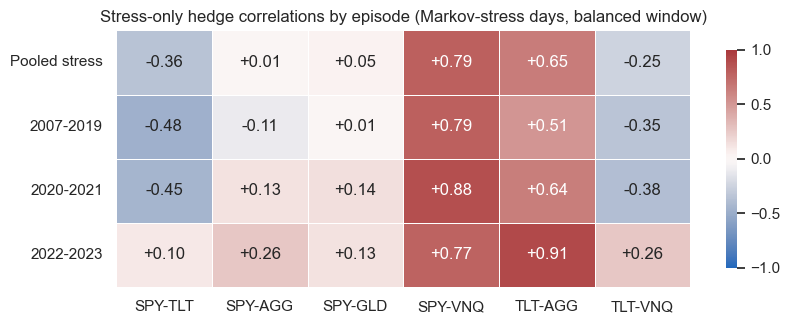

In [21]:
# --- Heatmap of the compact table (episodes x hedge pairs) ---
heat = compact_table.set_index("episode")[[f"{a}-{b}" for a, b in COMPACT_PAIRS]]
fig, ax = plt.subplots(figsize=(8.6, 3.4))
sns.heatmap(
    heat, ax=ax, vmin=-1, vmax=1, center=0, cmap="vlag",
    annot=True, fmt="+.2f", linewidths=0.5, cbar_kws={"shrink": 0.85},
)
ax.set_title("Stress-only hedge correlations by episode (Markov-stress days, balanced window)")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "stress_episode_hedge_correlation_heatmap.png", dpi=180, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "stress_episode_hedge_correlation_heatmap.pdf", bbox_inches="tight")
plt.show()


### Interpretation

- **Which pairs show the strongest stress-episode heterogeneity?** The flips concentrate in the duration sleeve. Ranked by (sign flip, max-minus-min range): HYG-TLT (range 0.96, +0.44 in 2022-23), AGG-HYG (0.86), TLT-VNQ (0.81), SPY-TLT (0.76), followed by the international-equity-vs-TLT pairs and the SHY-linked hedges. 22 of 91 pairs sign-flip; 43 change descriptive class.
- **Does SPY-TLT flip or weaken in 2022-2023?** It flips: -0.48 (2007-19 stress) and -0.45 (2020-21 stress) versus **+0.10** in 2022-23 stress.
- **Is the pooled Treasury hedge dominated by earlier deflationary stress episodes?** Yes. 2007-2019 and 2020-2021 supply 1,725 of the 2,268 stress days (~76%), so the pooled -0.36 mostly reflects deflationary-type stress.
- **Does this reinforce or qualify the Panel A cross-asset story?** Both. The pooled result stands on average, but the Treasury hedge is episode-type-dependent, while **SPY-GLD stays within [+0.01, +0.15] in every episode** --- gold's diversification is episode-robust, sovereign duration's is not.
- **Is the result clean enough to mention in the report?** Yes: integrated as one compact appendix table (broad eras x six hedge pairs), one closing paragraph in Section 5.1, and one limitation sentence. Descriptive only; 2024-25 contains just 42 stress days (below the 100-day threshold) and is excluded from the compact table.


## 15. Close Connection

In [22]:
con.close()